# Project: Ecommerce Sales Analysis



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_dataset - ecommerce_dataset.csv")
df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0


## 1. Check Data Types

In [2]:
df.dtypes

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

## 2. Drop Irrelevant Columns

In [9]:
df = df.drop(columns=["Latitude", "Longtitude"])

KeyError: "['Latitude', 'Longtitude'] not found in axis"

In [10]:
print(df.columns.tolist())
df = df.drop(columns=["Latitude", "Longtitude"], errors="ignore")
print(df.columns.tolist())

['order_id', 'product', 'category', 'price', 'quantity', 'payment_method', 'date', 'total', 'Month', 'Discount', 'City Code', 'Order Priority Code']
['order_id', 'product', 'category', 'price', 'quantity', 'payment_method', 'date', 'total', 'Month', 'Discount', 'City Code', 'Order Priority Code']


## 3. Rename Columns

In [11]:
df = df.rename(columns={"City Code": "City", "Order Priority Code": "Order Priority"})
df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN


## 4. Check Duplicate Rows

In [21]:
df.duplicated().sum()

np.int64(0)

## 5. Drop Duplicate Records

In [13]:
df = df.drop_duplicates()
print("Records after removing duplicates:", len(df))

Records after removing duplicates: 500


## 6. Check Missing and Null Values

In [14]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

## 7. Fill Missing Sales Value by Median

In [15]:
df["total"] = df["total"].fillna(df["total"].median())
df["total"].isnull().sum()

np.int64(0)

## EDA 1 — Top 5 Best Selling Products

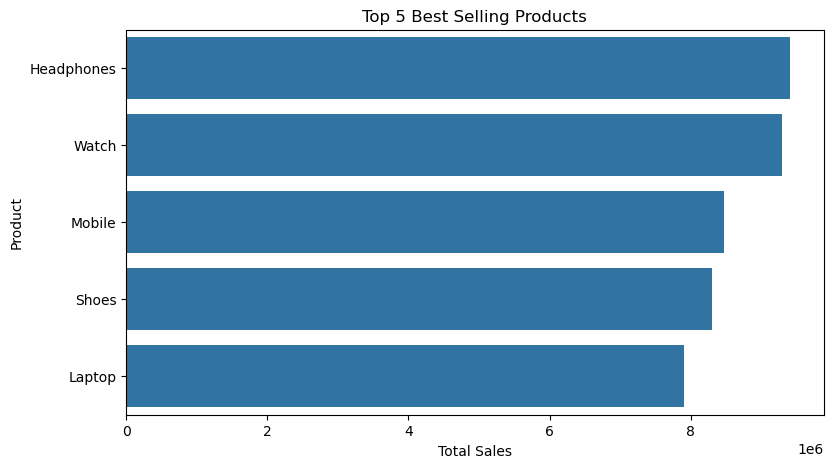

Observation: The best-selling product is Headphones


In [16]:
top_products = df.groupby("product")["total"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(9,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 5 Best Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

print("Observation: The best-selling product is", top_products.index[0])

## EDA 2 — Payment Method Distribution

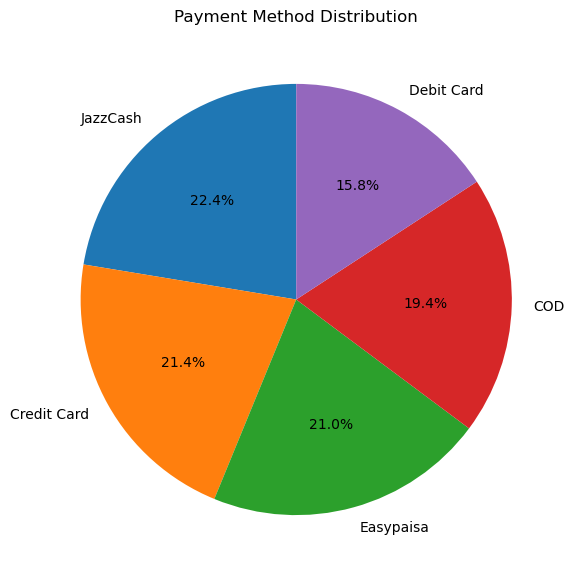

Observation: The most commonly used payment method is JazzCash


In [17]:
payment_counts = df["payment_method"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Payment Method Distribution")
plt.show()

print("Observation: The most commonly used payment method is", payment_counts.index[0])

## EDA 3 — Month-wise Sales

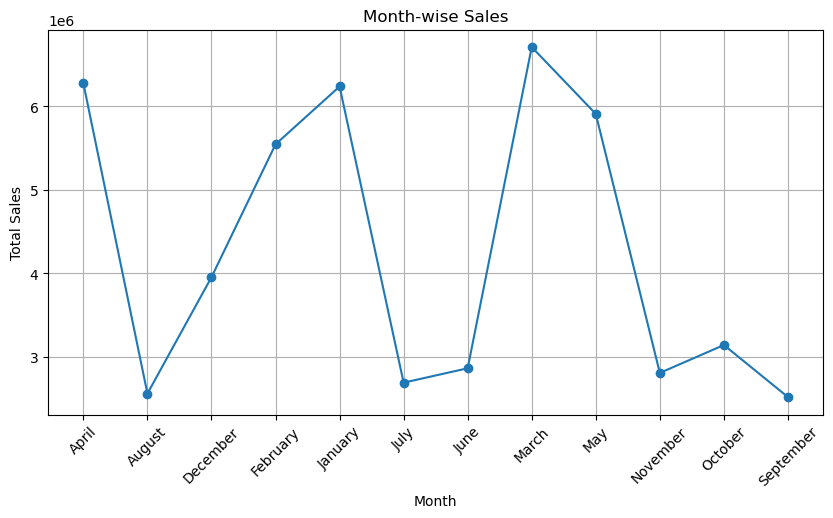

Observation: The highest-sales month is March


In [18]:
month_sales = df.groupby("Month")["total"].sum()

plt.figure(figsize=(10,5))
plt.plot(month_sales.index, month_sales.values, marker="o")
plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

print("Observation: The highest-sales month is", month_sales.idxmax())

## EDA 4 — City-wise Sales

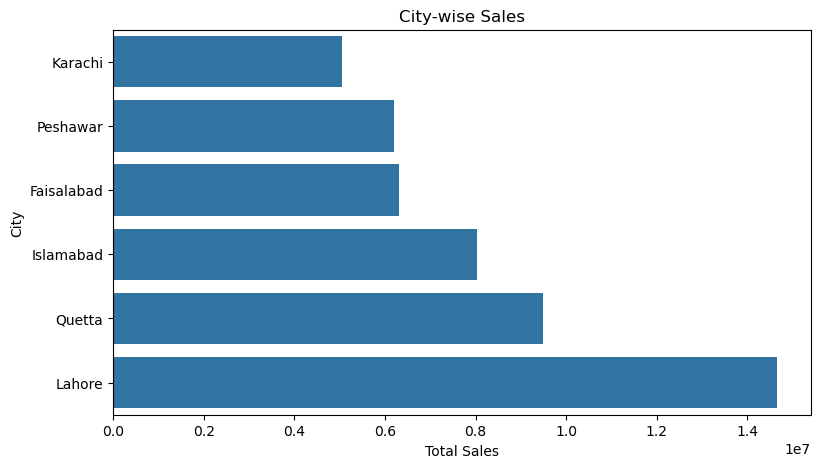

Observation: The city with the highest sales is Lahore


In [19]:
city_names = {1:"Karachi", 2:"Lahore", 3:"Islamabad", 4:"Faisalabad", 5:"Quetta", 6:"Peshawar"}
df["City"] = df["City"].replace(city_names)

city_sales = df.groupby("City")["total"].sum().sort_values()

plt.figure(figsize=(9,5))
sns.barplot(x=city_sales.values, y=city_sales.index)
plt.title("City-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()

print("Observation: The city with the highest sales is", city_sales.idxmax())

## EDA 5 — Monthly Sales by Category

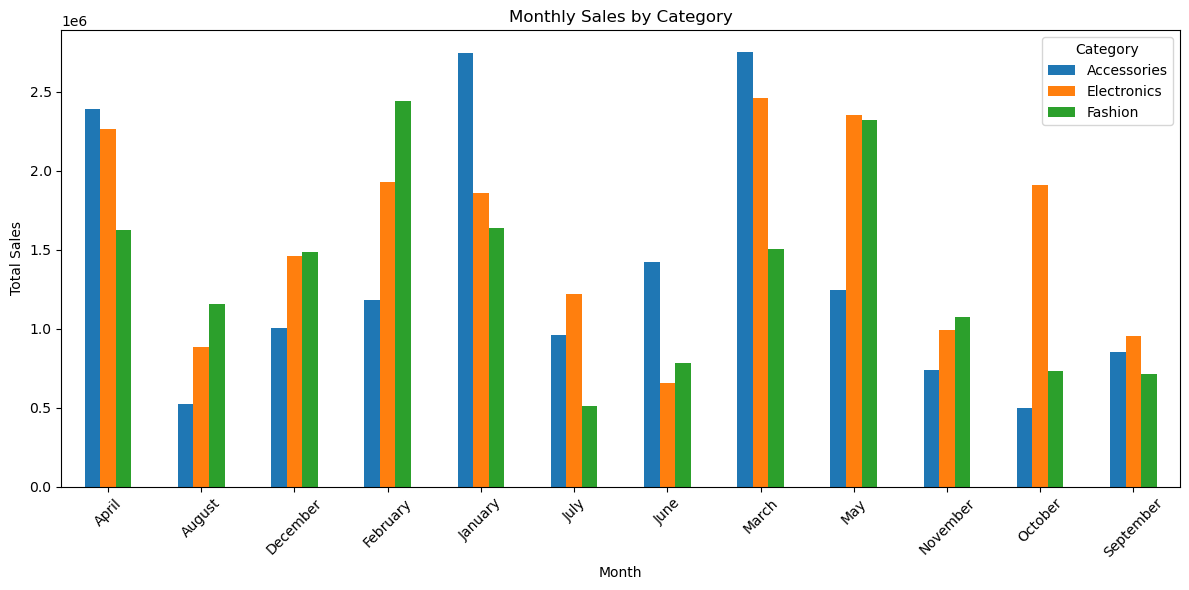

Observation: The chart compares category sales across each month.


In [20]:
monthly_category = df.groupby(["Month", "category"])["total"].sum().unstack(fill_value=0)

monthly_category.plot(kind="bar", figsize=(12,6))
plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

print("Observation: The chart compares category sales across each month.")